In [1]:
from pathlib import Path
import time
import pandas as pd
import matplotlib.pyplot as plt

from insertionPy import insertion_sort as insertion_py
from mergesort2Py import mergesort as mergesort_py
from quicksortPy import quicksort as quicksort_py

# ============================================================================
# CONFIGURAÇÃO DO BENCHMARK
# ============================================================================
print("=" * 70)
print("ANÁLISE DE COMPLEXIDADE - ALGORITMOS DE ORDENAÇÃO")
print("=" * 70)
print("Comparação entre Python e C")
print("Tamanhos: 1.000, 50.000, 150.000 elementos")
print("Perfis: Crescente, Decrescente, Aleatório")
print("\nMELHORIAS IMPLEMENTADAS:")
print("  • Quick Sort usa pivô ALEATÓRIO (Randomized Quick Sort)")
print("  • Evita O(n²) em dados ordenados e stack overflow")
print("  • Insertion Sort limitado a N≤50k (O(n²) é muito lento)")
print("=" * 70)

[0, 1, 3, 5, 5, 8, 9, 11, 14, 17, 19, 23, 28, 28, 34, 39, 39, 42, 47, 55, 61, 68, 76, 90, 100]
[0, 1, 3, 5, 5, 8, 9, 11, 14, 17, 19, 23, 28, 28, 34, 39, 39, 42, 47, 55, 61, 68, 76, 90, 100]
[0, 1, 3, 5, 5, 8, 9, 11, 14, 17, 19, 23, 28, 28, 34, 39, 39, 42, 47, 55, 61, 68, 76, 90, 100]
ANÁLISE DE COMPLEXIDADE - ALGORITMOS DE ORDENAÇÃO
Comparação entre Python e C
Tamanhos: 1.000, 50.000, 150.000 elementos
Perfis: Crescente, Decrescente, Aleatório

MELHORIAS IMPLEMENTADAS:
  • Quick Sort usa pivô ALEATÓRIO (Randomized Quick Sort)
  • Evita O(n²) em dados ordenados e stack overflow
  • Insertion Sort limitado a N≤50k (O(n²) é muito lento)


In [2]:
import random

# ============================================================================
# GERAÇÃO UNIFICADA DE VETORES - USADOS EM TODOS OS BENCHMARKS
# ============================================================================
# Fixa a seed para garantir reprodutibilidade
random.seed(42)

# Função para gerar vetores de diferentes tamanhos e perfis
def gerar_vetor(tamanho, perfil):
    """Gera um vetor com o perfil especificado"""
    if perfil == "Crescente":
        return list(range(tamanho))
    elif perfil == "Decrescente":
        return list(range(tamanho, 0, -1))
    elif perfil == "Aleatório":
        vetor = list(range(tamanho))
        random.shuffle(vetor)
        return vetor

# Tamanhos para análise (ajustados para evitar problemas com algoritmos O(n²))
# Para algoritmos eficientes: 1K, 50K, 150K
# Para Insertion Sort: apenas testado até 50K
TAMANHOS = [1000, 50000, 150000]

# Gera TODOS os vetores uma única vez - serão usados por Python E C
VETORES = {}
for tamanho in TAMANHOS:
    VETORES[tamanho] = {
        "Crescente": gerar_vetor(tamanho, "Crescente"),
        "Decrescente": gerar_vetor(tamanho, "Decrescente"),
        "Aleatório": gerar_vetor(tamanho, "Aleatório"),
    }

print("=" * 70)
print("VETORES GERADOS (seed=42 para reprodutibilidade)")
print("=" * 70)
print(f"Tamanhos: {TAMANHOS}")
print(f"Perfis: Crescente, Decrescente, Aleatório")
print(f"\nTotal de vetores: {len(TAMANHOS) * 3}")
print("Estes vetores serão usados em TODOS os benchmarks (Python e C)")
print("\nNOTA: Quick Sort usa pivô ALEATÓRIO para evitar O(n²) em dados ordenados")
print("=" * 70)

VETORES GERADOS (seed=42 para reprodutibilidade)
Tamanhos: [1000, 50000, 150000]
Perfis: Crescente, Decrescente, Aleatório

Total de vetores: 9
Estes vetores serão usados em TODOS os benchmarks (Python e C)

NOTA: Quick Sort usa pivô ALEATÓRIO para evitar O(n²) em dados ordenados


In [3]:
def run_insertion(arr):
    arr_copy = arr[:]               # preserva o original para outros algoritmos
    insertion_py(arr_copy, len(arr_copy))
    return arr_copy

def run_merge(arr):
    arr_copy = arr[:]
    mergesort_py(arr_copy, 0, len(arr_copy) - 1)
    return arr_copy

def run_quick(arr):
    arr_copy = arr[:]
    quicksort_py(arr_copy, 0, len(arr_copy) - 1)
    return arr_copy

ALGORITHMS = {
    "Insertion Sort": run_insertion,
    "Merge Sort": run_merge,
    "Quick Sort": run_quick,
}


In [4]:
import sys
sys.setrecursionlimit(300000)

# ============================================================================
# CONFIGURAÇÃO GLOBAL
# ============================================================================
REPETICOES = 3

# Vamos criar DataFrames separados para cada algoritmo
print("=" * 70)
print("BENCHMARKS SEPARADOS POR ALGORITMO")
print("=" * 70)
print(f"Cada algoritmo será testado em um bloco separado")
print(f"Repetições por teste: {REPETICOES}")
print("=" * 70)

BENCHMARKS SEPARADOS POR ALGORITMO
Cada algoritmo será testado em um bloco separado
Repetições por teste: 3


In [5]:
# ============================================================================
# BENCHMARK: INSERTION SORT (Python)
# ============================================================================
print("Testando Insertion Sort (Python)...")
print("Tamanhos: 1.000 e 50.000 (pulando 150k por ser O(n²))\n")

linhas_insertion_py = []
for tamanho in [1000, 50000]:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_insertion(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_insertion_py.append({
                "Algoritmo": "Insertion Sort",
                "Linguagem": "Python",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_insertion_py = pd.DataFrame(linhas_insertion_py)
print(f"\n✓ Insertion Sort (Python) completo! {len(linhas_insertion_py)} testes")
df_insertion_py.groupby(["N", "Perfil"])["Tempo (s)"].mean()

Testando Insertion Sort (Python)...
Tamanhos: 1.000 e 50.000 (pulando 150k por ser O(n²))

  ✓ N=  1000, Crescente    - 0.0001s
  ✓ N=  1000, Crescente    - 0.0001s
  ✓ N=  1000, Crescente    - 0.0001s
  ✓ N=  1000, Decrescente  - 0.0151s
  ✓ N=  1000, Decrescente  - 0.0146s
  ✓ N=  1000, Decrescente  - 0.0161s
  ✓ N=  1000, Aleatório    - 0.0085s
  ✓ N=  1000, Aleatório    - 0.0077s
  ✓ N=  1000, Aleatório    - 0.0077s
  ✓ N= 50000, Crescente    - 0.0023s
  ✓ N= 50000, Crescente    - 0.0021s
  ✓ N= 50000, Crescente    - 0.0020s
  ✓ N= 50000, Decrescente  - 42.5955s
  ✓ N= 50000, Decrescente  - 41.3520s
  ✓ N= 50000, Decrescente  - 41.0974s
  ✓ N= 50000, Aleatório    - 20.7078s
  ✓ N= 50000, Aleatório    - 20.7371s
  ✓ N= 50000, Aleatório    - 20.7478s

✓ Insertion Sort (Python) completo! 18 testes


N      Perfil     
1000   Aleatório       0.007986
       Crescente       0.000065
       Decrescente     0.015270
50000  Aleatório      20.730909
       Crescente       0.002122
       Decrescente    41.681621
Name: Tempo (s), dtype: float64

# ============================================================================
# BENCHMARK: MERGE SORT (Python)
# ============================================================================
print("Testando Merge Sort (Python)...")
print("Tamanhos: 1.000, 50.000, 150.000\n")

linhas_merge_py = []
for tamanho in TAMANHOS:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_merge(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_merge_py.append({
                "Algoritmo": "Merge Sort",
                "Linguagem": "Python",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_merge_py = pd.DataFrame(linhas_merge_py)
print(f"\n✓ Merge Sort (Python) completo! {len(linhas_merge_py)} testes")
df_merge_py.groupby(["N", "Perfil"])["Tempo (s)"].mean()

In [6]:
# ============================================================================
# BENCHMARK: QUICK SORT (Python)
# ============================================================================
print("Testando Quick Sort (Python)...")
print("Tamanhos: 1.000, 50.000, 150.000")
print("NOTA: Python usa pivô fixo (último elemento)\n")

linhas_quick_py = []
for tamanho in TAMANHOS:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_quick(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_quick_py.append({
                "Algoritmo": "Quick Sort",
                "Linguagem": "Python",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_quick_py = pd.DataFrame(linhas_quick_py)
print(f"\n✓ Quick Sort (Python) completo! {len(linhas_quick_py)} testes")
df_quick_py.groupby(["N", "Perfil"])["Tempo (s)"].mean()

Testando Quick Sort (Python)...
Tamanhos: 1.000, 50.000, 150.000
NOTA: Python usa pivô fixo (último elemento)

  ✓ N=  1000, Crescente    - 0.0185s
  ✓ N=  1000, Crescente    - 0.0192s
  ✓ N=  1000, Crescente    - 0.0184s
  ✓ N=  1000, Decrescente  - 0.0129s
  ✓ N=  1000, Decrescente  - 0.0128s
  ✓ N=  1000, Decrescente  - 0.0126s
  ✓ N=  1000, Aleatório    - 0.0005s
  ✓ N=  1000, Aleatório    - 0.0005s
  ✓ N=  1000, Aleatório    - 0.0005s
  ✓ N= 50000, Crescente    - 47.6836s
  ✓ N= 50000, Crescente    - 48.4914s
  ✓ N= 50000, Crescente    - 48.0443s
  ✓ N= 50000, Decrescente  - 32.6991s
  ✓ N= 50000, Decrescente  - 32.6548s
  ✓ N= 50000, Decrescente  - 33.5407s
  ✓ N= 50000, Aleatório    - 0.0379s
  ✓ N= 50000, Aleatório    - 0.0361s
  ✓ N= 50000, Aleatório    - 0.0360s
  ✓ N=150000, Crescente    - 441.7369s
  ✓ N=150000, Crescente    - 438.2733s
  ✓ N=150000, Crescente    - 437.8051s
  ✓ N=150000, Decrescente  - 302.2732s
  ✓ N=150000, Decrescente  - 302.9939s
  ✓ N=150000, Decresce

N       Perfil     
1000    Aleatório        0.000476
        Crescente        0.018717
        Decrescente      0.012772
50000   Aleatório        0.036634
        Crescente       48.073115
        Decrescente     32.964877
150000  Aleatório        0.141334
        Crescente      439.271777
        Decrescente    304.590480
Name: Tempo (s), dtype: float64

In [8]:
import ctypes
import subprocess
import os

# ============================================================================
# COMPILAÇÃO DOS ALGORITMOS C
# ============================================================================
def compile_c_library(source_file, output_name):
    """Compila um arquivo .c em uma biblioteca compartilhada (.so)"""
    cmd = ["gcc", "-shared", "-fPIC", "-O2", source_file, "-o", f"{output_name}.so"]
    subprocess.run(cmd, check=True)
    return f"{output_name}.so"

# Compila todos os algoritmos C
c_algorithms = {
    "insertion": "insertion.c",
    "mergesort2": "mergesort2.c", 
    "quicksort": "quicksort.c",
    "heapsort": "heapsort.c"
}

libs = {}
for name, source in c_algorithms.items():
    if os.path.exists(source):
        lib_path = compile_c_library(source, name)
        libs[name] = ctypes.CDLL(f"./{lib_path}")
        print(f"✓ Compilado: {name}")

print(f"\nBibliotecas C disponíveis: {list(libs.keys())}")

# ============================================================================
# WRAPPERS PARA FUNÇÕES C
# ============================================================================
def run_c_insertion(arr):
    n = len(arr)
    arr_c = (ctypes.c_int * n)(*arr)
    libs["insertion"].insertion_sort(arr_c, n)
    return list(arr_c)

def run_c_merge(arr):
    n = len(arr)
    arr_c = (ctypes.c_int * n)(*arr)
    libs["mergesort2"].mergesort2(arr_c, 0, n - 1)
    return list(arr_c)

def run_c_quick(arr):
    n = len(arr)
    arr_c = (ctypes.c_int * n)(*arr)
    libs["quicksort"].quicksort(arr_c, 0, n - 1)
    return list(arr_c)

def run_c_heap(arr):
    n = len(arr)
    arr_c = (ctypes.c_int * n)(*arr)
    libs["heapsort"].heapsort2(arr_c, n)
    return list(arr_c)

# Teste rápido
test_arr = [64, 34, 25, 12, 22, 11, 90]
print(f"\nTeste com {test_arr}:")
print(f"  Insertion Sort (C): {run_c_insertion(test_arr[:])}")
print(f"  Merge Sort (C): {run_c_merge(test_arr[:])}")
print(f"  Quick Sort (C): {run_c_quick(test_arr[:])}")
print(f"  Heap Sort (C): {run_c_heap(test_arr[:])}")

✓ Compilado: insertion
✓ Compilado: mergesort2
✓ Compilado: quicksort
✓ Compilado: heapsort

Bibliotecas C disponíveis: ['insertion', 'mergesort2', 'quicksort', 'heapsort']

Teste com [64, 34, 25, 12, 22, 11, 90]:
  Insertion Sort (C): [11, 12, 22, 25, 34, 64, 90]
  Merge Sort (C): [11, 12, 22, 25, 34, 64, 90]
  Quick Sort (C): [11, 12, 22, 25, 34, 64, 90]
  Heap Sort (C): [11, 12, 22, 25, 34, 90, 64]


In [9]:
# ============================================================================
# BENCHMARK: INSERTION SORT (C)
# ============================================================================
print("Testando Insertion Sort (C)...")
print("Tamanhos: 1.000 e 50.000 (pulando 150k por ser O(n²))\n")

linhas_insertion_c = []
for tamanho in [1000, 50000]:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_c_insertion(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_insertion_c.append({
                "Algoritmo": "Insertion Sort",
                "Linguagem": "C",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_insertion_c = pd.DataFrame(linhas_insertion_c)
print(f"\n✓ Insertion Sort (C) completo! {len(linhas_insertion_c)} testes")
df_insertion_c.groupby(["N", "Perfil"])["Tempo (s)"].mean()

Testando Insertion Sort (C)...
Tamanhos: 1.000 e 50.000 (pulando 150k por ser O(n²))

  ✓ N=  1000, Crescente    - 0.0002s
  ✓ N=  1000, Crescente    - 0.0001s
  ✓ N=  1000, Crescente    - 0.0001s
  ✓ N=  1000, Decrescente  - 0.0004s
  ✓ N=  1000, Decrescente  - 0.0003s
  ✓ N=  1000, Decrescente  - 0.0003s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N= 50000, Crescente    - 0.0064s
  ✓ N= 50000, Crescente    - 0.0067s
  ✓ N= 50000, Crescente    - 0.0061s
  ✓ N= 50000, Decrescente  - 0.2898s
  ✓ N= 50000, Decrescente  - 0.2955s
  ✓ N= 50000, Decrescente  - 0.2900s
  ✓ N= 50000, Aleatório    - 0.1479s
  ✓ N= 50000, Aleatório    - 0.1488s
  ✓ N= 50000, Aleatório    - 0.1468s

✓ Insertion Sort (C) completo! 18 testes


N      Perfil     
1000   Aleatório      0.000179
       Crescente      0.000144
       Decrescente    0.000300
50000  Aleatório      0.147832
       Crescente      0.006361
       Decrescente    0.291763
Name: Tempo (s), dtype: float64

In [10]:
# ============================================================================
# BENCHMARK: MERGE SORT (C)
# ============================================================================
print("Testando Merge Sort (C)...")
print("Tamanhos: 1.000, 50.000, 150.000\n")

linhas_merge_c = []
for tamanho in TAMANHOS:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_c_merge(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_merge_c.append({
                "Algoritmo": "Merge Sort",
                "Linguagem": "C",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_merge_c = pd.DataFrame(linhas_merge_c)
print(f"\n✓ Merge Sort (C) completo! {len(linhas_merge_c)} testes")
df_merge_c.groupby(["N", "Perfil"])["Tempo (s)"].mean()

Testando Merge Sort (C)...
Tamanhos: 1.000, 50.000, 150.000

  ✓ N=  1000, Crescente    - 0.0005s
  ✓ N=  1000, Crescente    - 0.0005s
  ✓ N=  1000, Crescente    - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0003s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N= 50000, Crescente    - 0.0075s
  ✓ N= 50000, Crescente    - 0.0084s
  ✓ N= 50000, Crescente    - 0.0073s
  ✓ N= 50000, Decrescente  - 0.0071s
  ✓ N= 50000, Decrescente  - 0.0070s
  ✓ N= 50000, Decrescente  - 0.0071s
  ✓ N= 50000, Aleatório    - 0.0094s
  ✓ N= 50000, Aleatório    - 0.0095s
  ✓ N= 50000, Aleatório    - 0.0094s
  ✓ N=150000, Crescente    - 0.0234s
  ✓ N=150000, Crescente    - 0.0227s
  ✓ N=150000, Crescente    - 0.0247s
  ✓ N=150000, Decrescente  - 0.0237s
  ✓ N=150000, Decrescente  - 0.0236s
  ✓ N=150000, Decrescente  - 0.0249s
  ✓ N=150000, Aleatório    - 0.0349s
  ✓ N=150000, 

N       Perfil     
1000    Aleatório      0.000239
        Crescente      0.000372
        Decrescente    0.000155
50000   Aleatório      0.009422
        Crescente      0.007719
        Decrescente    0.007080
150000  Aleatório      0.033178
        Crescente      0.023602
        Decrescente    0.024083
Name: Tempo (s), dtype: float64

In [11]:
# ============================================================================
# BENCHMARK: QUICK SORT (C - com pivô aleatório)
# ============================================================================
print("Testando Quick Sort (C)...")
print("Tamanhos: 1.000, 50.000, 150.000")
print("NOTA: C usa pivô ALEATÓRIO (Randomized Quick Sort)\n")

linhas_quick_c = []
for tamanho in TAMANHOS:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_c_quick(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_quick_c.append({
                "Algoritmo": "Quick Sort",
                "Linguagem": "C",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_quick_c = pd.DataFrame(linhas_quick_c)
print(f"\n✓ Quick Sort (C) completo! {len(linhas_quick_c)} testes")
df_quick_c.groupby(["N", "Perfil"])["Tempo (s)"].mean()

Testando Quick Sort (C)...
Tamanhos: 1.000, 50.000, 150.000
NOTA: C usa pivô ALEATÓRIO (Randomized Quick Sort)

  ✓ N=  1000, Crescente    - 0.0002s
  ✓ N=  1000, Crescente    - 0.0007s
  ✓ N=  1000, Crescente    - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0003s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0004s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0004s
  ✓ N= 50000, Crescente    - 0.0077s
  ✓ N= 50000, Crescente    - 0.0076s
  ✓ N= 50000, Crescente    - 0.0070s
  ✓ N= 50000, Decrescente  - 0.0071s
  ✓ N= 50000, Decrescente  - 0.0071s
  ✓ N= 50000, Decrescente  - 0.0070s
  ✓ N= 50000, Aleatório    - 0.0085s
  ✓ N= 50000, Aleatório    - 0.0087s
  ✓ N= 50000, Aleatório    - 0.0087s
  ✓ N=150000, Crescente    - 0.0223s
  ✓ N=150000, Crescente    - 0.0236s
  ✓ N=150000, Crescente    - 0.0227s
  ✓ N=150000, Decrescente  - 0.0225s
  ✓ N=150000, Decrescente  - 0.0224s
  ✓ N=150000, Decrescente  - 0.0244s


N       Perfil     
1000    Aleatório      0.000343
        Crescente      0.000362
        Decrescente    0.000205
50000   Aleatório      0.008654
        Crescente      0.007439
        Decrescente    0.007036
150000  Aleatório      0.030529
        Crescente      0.022843
        Decrescente    0.023100
Name: Tempo (s), dtype: float64

In [12]:
# ============================================================================
# BENCHMARK: HEAP SORT (C)
# ============================================================================
print("Testando Heap Sort (C)...")
print("Tamanhos: 1.000, 50.000, 150.000\n")

linhas_heap_c = []
for tamanho in TAMANHOS:
    for perfil in ["Crescente", "Decrescente", "Aleatório"]:
        vetor = VETORES[tamanho][perfil]
        
        for rep in range(REPETICOES):
            inicio = time.perf_counter()
            run_c_heap(vetor)
            duracao = time.perf_counter() - inicio
            
            linhas_heap_c.append({
                "Algoritmo": "Heap Sort",
                "Linguagem": "C",
                "Perfil": perfil,
                "N": tamanho,
                "Tempo (s)": duracao,
            })
            print(f"  ✓ N={tamanho:6}, {perfil:12} - {duracao:.4f}s")

df_heap_c = pd.DataFrame(linhas_heap_c)
print(f"\n✓ Heap Sort (C) completo! {len(linhas_heap_c)} testes")
df_heap_c.groupby(["N", "Perfil"])["Tempo (s)"].mean()

Testando Heap Sort (C)...
Tamanhos: 1.000, 50.000, 150.000

  ✓ N=  1000, Crescente    - 0.0002s
  ✓ N=  1000, Crescente    - 0.0001s
  ✓ N=  1000, Crescente    - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Decrescente  - 0.0003s
  ✓ N=  1000, Decrescente  - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N=  1000, Aleatório    - 0.0003s
  ✓ N=  1000, Aleatório    - 0.0002s
  ✓ N= 50000, Crescente    - 0.0074s
  ✓ N= 50000, Crescente    - 0.0081s
  ✓ N= 50000, Crescente    - 0.0075s
  ✓ N= 50000, Decrescente  - 0.0073s
  ✓ N= 50000, Decrescente  - 0.0077s
  ✓ N= 50000, Decrescente  - 0.0072s
  ✓ N= 50000, Aleatório    - 0.0082s
  ✓ N= 50000, Aleatório    - 0.0081s
  ✓ N= 50000, Aleatório    - 0.0080s
  ✓ N=150000, Crescente    - 0.0232s
  ✓ N=150000, Crescente    - 0.0243s
  ✓ N=150000, Crescente    - 0.0257s
  ✓ N=150000, Decrescente  - 0.0252s
  ✓ N=150000, Decrescente  - 0.0255s
  ✓ N=150000, Decrescente  - 0.0251s
  ✓ N=150000, Aleatório    - 0.0315s
  ✓ N=150000, A

N       Perfil     
1000    Aleatório      0.000198
        Crescente      0.000182
        Decrescente    0.000236
50000   Aleatório      0.008088
        Crescente      0.007666
        Decrescente    0.007426
150000  Aleatório      0.028931
        Crescente      0.024415
        Decrescente    0.025262
Name: Tempo (s), dtype: float64

In [14]:
# ============================================================================
# COMBINA TODOS OS RESULTADOS
# ============================================================================
print("Combinando todos os resultados...")

# Combina todos os DataFrames
todos_resultados = pd.concat([
    df_insertion_py,
    df_insertion_c,
    df_merge_c,
    df_quick_py,
    df_quick_c,
    df_heap_c
], ignore_index=True)

# Calcula médias por algoritmo, linguagem, perfil e tamanho
resultados_medios = todos_resultados.groupby(
    ["Algoritmo", "Linguagem", "Perfil", "N"]
)["Tempo (s)"].mean().reset_index()

print(f"\n✓ Total de {len(todos_resultados)} testes individuais")
print(f"✓ {len(resultados_medios)} combinações únicas")
print("\nPrimeiras linhas:")
resultados_medios.head(15)

Combinando todos os resultados...

✓ Total de 144 testes individuais
✓ 48 combinações únicas

Primeiras linhas:


,Algoritmo,Linguagem,Perfil,N,Tempo (s)
0,Heap Sort,C,Aleatório,1000,0.000198
1,Heap Sort,C,Aleatório,50000,0.008088
2,Heap Sort,C,Aleatório,150000,0.028931
3,Heap Sort,C,Crescente,1000,0.000182
4,Heap Sort,C,Crescente,50000,0.007666
5,Heap Sort,C,Crescente,150000,0.024415
6,Heap Sort,C,Decrescente,1000,0.000236
7,Heap Sort,C,Decrescente,50000,0.007426
8,Heap Sort,C,Decrescente,150000,0.025262
9,Insertion Sort,C,Aleatório,1000,0.000179


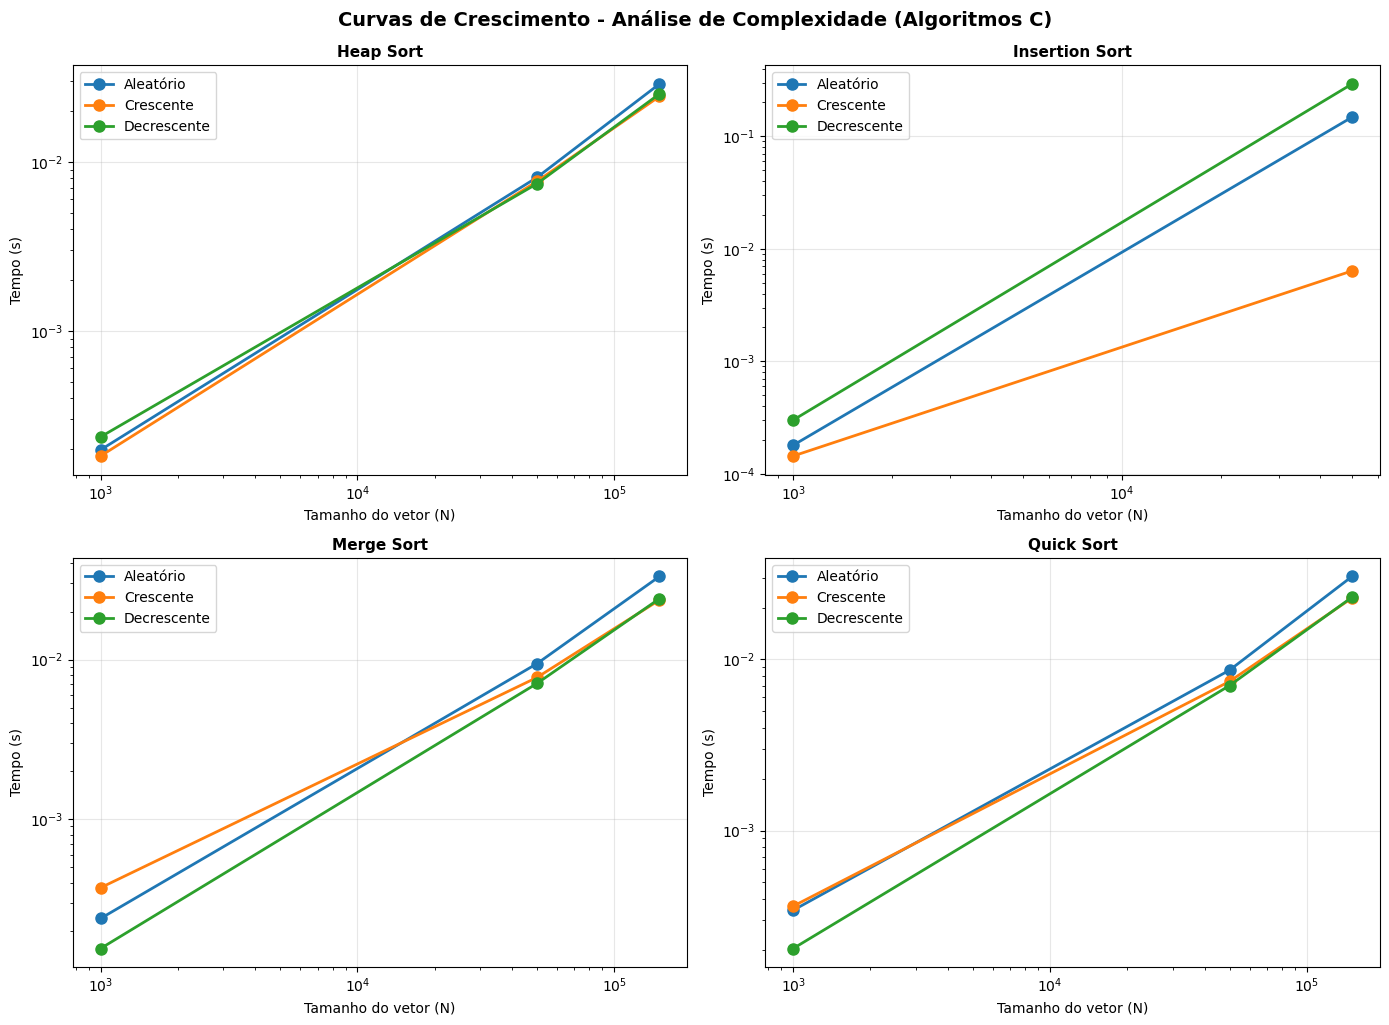

In [16]:
# ============================================================================
# CURVAS DE CRESCIMENTO - ANÁLISE DE COMPLEXIDADE
# ============================================================================

# Filter only C algorithms from the combined results
resultados_c_medios = resultados_medios[resultados_medios["Linguagem"] == "C"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

algoritmos_c = resultados_c_medios["Algoritmo"].unique()

for idx, algoritmo in enumerate(algoritmos_c):
    ax = axes[idx]
    dados_alg = resultados_c_medios[resultados_c_medios["Algoritmo"] == algoritmo]
    
    for perfil in ["Aleatório", "Crescente", "Decrescente"]:
        dados_perfil = dados_alg[dados_alg["Perfil"] == perfil].sort_values("N")
        ax.plot(dados_perfil["N"], dados_perfil["Tempo (s)"], marker="o", label=perfil, linewidth=2, markersize=8)
    
    ax.set_xlabel("Tamanho do vetor (N)", fontsize=10)
    ax.set_ylabel("Tempo (s)", fontsize=10)
    ax.set_title(algoritmo.replace(" (C)", ""), fontsize=11, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.suptitle("Curvas de Crescimento - Análise de Complexidade (Algoritmos C)", fontsize=14, fontweight="bold", y=1.02)
plt.show()

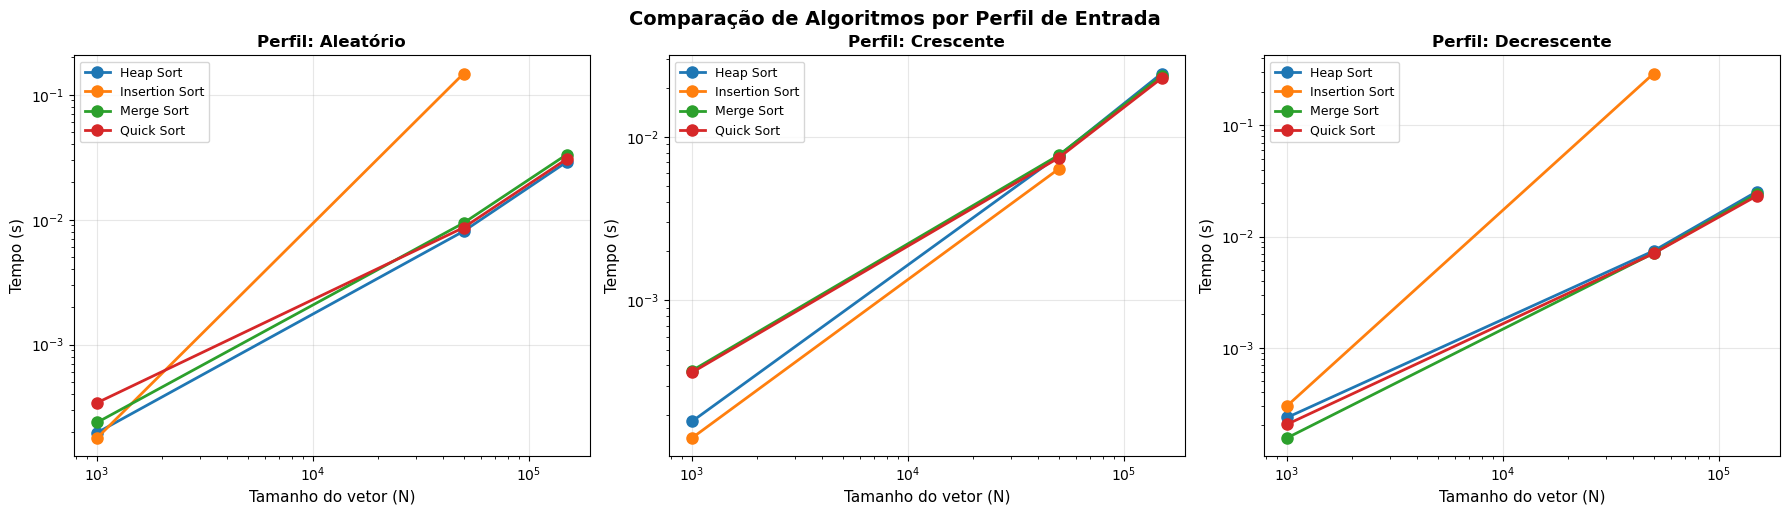

In [17]:
# ============================================================================
# COMPARAÇÃO DE ALGORITMOS POR PERFIL DE ENTRADA
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
perfis = ["Aleatório", "Crescente", "Decrescente"]

for idx, perfil in enumerate(perfis):
    ax = axes[idx]
    dados_perfil = resultados_c_medios[resultados_c_medios["Perfil"] == perfil]
    
    for algoritmo in algoritmos_c:
        dados_alg = dados_perfil[dados_perfil["Algoritmo"] == algoritmo].sort_values("N")
        label = algoritmo.replace(" (C)", "")
        ax.plot(dados_alg["N"], dados_alg["Tempo (s)"], marker="o", label=label, linewidth=2, markersize=8)
    
    ax.set_xlabel("Tamanho do vetor (N)", fontsize=11)
    ax.set_ylabel("Tempo (s)", fontsize=11)
    ax.set_title(f"Perfil: {perfil}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')

plt.tight_layout()
plt.suptitle("Comparação de Algoritmos por Perfil de Entrada", fontsize=14, fontweight="bold", y=1.02)
plt.show()

In [18]:
# ============================================================================
# TABELA DE TEMPOS PARA MAIOR TAMANHO (N=200000)
# ============================================================================
import numpy as np

maior_n = max(TAMANHOS)
dados_maior = resultados_c_medios[resultados_c_medios["N"] == maior_n].copy()
pivot_maior = dados_maior.pivot_table(
    index="Algoritmo", 
    columns="Perfil", 
    values="Tempo (s)"
)[["Crescente", "Aleatório", "Decrescente"]]

# Remove " (C)" do nome
pivot_maior.index = pivot_maior.index.str.replace(" \\(C\\)", "", regex=True)

print("=" * 70)
print(f"TEMPOS DE EXECUÇÃO PARA N = {maior_n:,} ELEMENTOS".replace(",", "."))
print("=" * 70)
print(pivot_maior.round(4))
print("\n")

# Identifica os melhores e piores casos
print("ANÁLISE:")
print("-" * 70)
for algoritmo in pivot_maior.index:
    tempos = pivot_maior.loc[algoritmo]
    melhor = tempos.idxmin()
    pior = tempos.idxmax()
    ratio = tempos[pior] / tempos[melhor] if tempos[melhor] > 0 else 0
    print(f"{algoritmo}:")
    print(f"  ✓ Melhor caso: {melhor:12} ({tempos[melhor]:.4f}s)")
    print(f"  ✗ Pior caso:   {pior:12} ({tempos[pior]:.4f}s)")
    print(f"  → Variação:    {ratio:.1f}x mais lento no pior caso")
    print()

TEMPOS DE EXECUÇÃO PARA N = 150.000 ELEMENTOS
Perfil      Crescente  Aleatório  Decrescente
Algoritmo                                    
Heap Sort      0.0244     0.0289       0.0253
Merge Sort     0.0236     0.0332       0.0241
Quick Sort     0.0228     0.0305       0.0231


ANÁLISE:
----------------------------------------------------------------------
Heap Sort:
  ✓ Melhor caso: Crescente    (0.0244s)
  ✗ Pior caso:   Aleatório    (0.0289s)
  → Variação:    1.2x mais lento no pior caso

Merge Sort:
  ✓ Melhor caso: Crescente    (0.0236s)
  ✗ Pior caso:   Aleatório    (0.0332s)
  → Variação:    1.4x mais lento no pior caso

Quick Sort:
  ✓ Melhor caso: Crescente    (0.0228s)
  ✗ Pior caso:   Aleatório    (0.0305s)
  → Variação:    1.3x mais lento no pior caso



In [19]:
# ============================================================================
# ANÁLISE DE TAXA DE CRESCIMENTO
# ============================================================================
print("=" * 70)
print("ANÁLISE DE TAXA DE CRESCIMENTO")
print("=" * 70)
print("Quanto o tempo aumenta ao aumentar N?\n")

for algoritmo in algoritmos_c:
    print(f"{algoritmo.replace(' (C)', '')}:")
    print("-" * 70)
    
    for perfil in ["Crescente", "Aleatório", "Decrescente"]:
        dados = resultados_c_medios[
            (resultados_c_medios["Algoritmo"] == algoritmo) &
            (resultados_c_medios["Perfil"] == perfil)
        ].sort_values("N")
        
        tempos = dados["Tempo (s)"].values
        tamanhos = dados["N"].values
        
        if len(tempos) >= 2:
            taxa_1 = tempos[1] / tempos[0] if tempos[0] > 0 else 0
            mult_1 = tamanhos[1] / tamanhos[0]
            
            if len(tempos) >= 3:
                taxa_2 = tempos[2] / tempos[1] if tempos[1] > 0 else 0
                mult_2 = tamanhos[2] / tamanhos[1]
                print(f"  {perfil:12} | {int(tamanhos[0])}→{int(tamanhos[1])}: {taxa_1:6.1f}x ({mult_1:.0f}x maior) | {int(tamanhos[1])}→{int(tamanhos[2])}: {taxa_2:6.1f}x ({mult_2:.1f}x maior)")
            else:
                print(f"  {perfil:12} | {int(tamanhos[0])}→{int(tamanhos[1])}: {taxa_1:6.1f}x ({mult_1:.0f}x maior)")
    
    print()

print("\nReferência teórica:")
print("  • O(n):        k×N = tempo cresce linearmente com N")
print("  • O(n log n):  k×N = tempo cresce ~k×1.3 vezes")
print("  • O(n²):       k×k×N = tempo cresce k² vezes")
print("\nExemplo: se N aumenta 50x, esperamos:")
print("  • O(n):        ~50x mais lento")
print("  • O(n log n):  ~65x mais lento (50 × log(50×N)/log(N))")
print("  • O(n²):       ~2500x mais lento (50²)")

ANÁLISE DE TAXA DE CRESCIMENTO
Quanto o tempo aumenta ao aumentar N?

Heap Sort:
----------------------------------------------------------------------
  Crescente    | 1000→50000:   42.2x (50x maior) | 50000→150000:    3.2x (3.0x maior)
  Aleatório    | 1000→50000:   40.9x (50x maior) | 50000→150000:    3.6x (3.0x maior)
  Decrescente  | 1000→50000:   31.5x (50x maior) | 50000→150000:    3.4x (3.0x maior)

Insertion Sort:
----------------------------------------------------------------------
  Crescente    | 1000→50000:   44.2x (50x maior)
  Aleatório    | 1000→50000:  823.8x (50x maior)
  Decrescente  | 1000→50000:  971.3x (50x maior)

Merge Sort:
----------------------------------------------------------------------
  Crescente    | 1000→50000:   20.8x (50x maior) | 50000→150000:    3.1x (3.0x maior)
  Aleatório    | 1000→50000:   39.5x (50x maior) | 50000→150000:    3.5x (3.0x maior)
  Decrescente  | 1000→50000:   45.8x (50x maior) | 50000→150000:    3.4x (3.0x maior)

Quick Sort:
